# 02. 합성 데이터 생성·검증

`generator.py`가 smoke 설정을 구조대로 구현하는지 검사한다. 모든 조건은 개별 메시지로 출력하고,
실패가 있으면 마지막 셀에서 실패 조건을 명시한 예외를 발생시킨다. 동일 seed의 결정론도 확인한다.

In [4]:
# 프로젝트 루트를 찾아 상대경로와 로컬 모듈 import를 일관되게 사용한다.
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("프로젝트 루트를 찾을 수 없습니다. 저장소 안에서 노트북을 실행하세요.")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
SEED = 20260826
PROJECT_ROOT

WindowsPath('D:/CODE/proj2/5pl')

In [5]:
# 기존 생성기·검증기를 import해 smoke 인스턴스를 생성하고 저장한다.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.config import load_config
from src.generator import generate_instance, save_instance
from src.validation import validate_instance

config = load_config("configs/smoke.json")
instance = generate_instance(config)
output_path = save_instance(instance, "data/generated/smoke/generated_instance.json")
print("생성 파일:", output_path.relative_to(PROJECT_ROOT))

생성 파일: data\generated\smoke\generated_instance.json


In [6]:
# 구매·공급 관계를 표 형태로 만들어 수량, 가격, 커버리지 검증에 사용한다.
buyer_rows = [{"buyer_id": b.buyer_id, "sku_id": sku, "min_qty": item.min_qty, "max_qty": item.max_qty,
               "wtp": item.wtp, "delivery_cost": b.delivery_cost}
              for b in instance.buyers.values() for sku, item in b.items.items()]
seller_rows = [{"seller_id": s.seller_id, "sku_id": sku, "capacity": item.capacity, "wta": item.wta}
               for s in instance.sellers.values() for sku, item in s.items.items()]
buyers_df, sellers_df = pd.DataFrame(buyer_rows), pd.DataFrame(seller_rows)
count_summary = pd.Series({"buyers": instance.num_buyers, "sellers": instance.num_sellers, "skus": instance.num_skus,
                           "buyer_item_rows": len(buyers_df), "seller_item_rows": len(sellers_df)})
display(count_summary)
display(buyers_df.describe(include="all"))
display(sellers_df.describe(include="all"))

buyers               8
sellers             10
skus                 5
buyer_item_rows     10
seller_item_rows    29
dtype: int64

,buyer_id,sku_id,min_qty,max_qty,wtp,delivery_cost
count,10,10,10.00000,10.000000,10.000000,10.000000
unique,8,5,NaN,NaN,NaN,NaN
top,B7,K5,NaN,NaN,NaN,NaN
freq,2,3,NaN,NaN,NaN,NaN
mean,NaN,NaN,10.20000,17.100000,98.256946,20.000000
std,NaN,NaN,3.32666,5.486347,27.023790,6.666667
min,NaN,NaN,4.00000,7.000000,75.034516,10.000000
25%,NaN,NaN,9.25000,15.250000,78.252419,20.000000
50%,NaN,NaN,10.00000,17.000000,82.561027,20.000000
75%,NaN,NaN,11.00000,18.750000,115.289568,20.000000


,seller_id,sku_id,capacity,wta
count,29,29,29.000000,29.000000
unique,10,5,NaN,NaN
top,S6,K2,NaN,NaN
freq,5,7,NaN,NaN
mean,NaN,NaN,5.896552,93.366264
std,NaN,NaN,5.236286,27.707084
min,NaN,NaN,0.458070,60.572304
25%,NaN,NaN,2.271255,68.072357
50%,NaN,NaN,4.247510,90.533964
75%,NaN,NaN,6.722681,112.356634


In [7]:
# 요구된 검증 조건을 각각 평가하고 실패 메시지를 구체적으로 남긴다.
checks = {
    "configured_counts": (instance.num_buyers == config["num_buyers"] and instance.num_sellers == config["num_sellers"] and instance.num_skus == config["num_skus"], "설정과 실제 구매자·공급자·품목 수가 다릅니다."),
    "buyer_item_counts": (buyers_df.groupby("buyer_id")["sku_id"].nunique().between(1, instance.num_skus).all(), "구매자별 주문 품목 수가 허용범위를 벗어납니다."),
    "seller_item_counts": (sellers_df.groupby("seller_id")["sku_id"].nunique().between(1, instance.num_skus).all(), "공급자별 취급 품목 수가 허용범위를 벗어납니다."),
    "every_seller_has_item": (set(sellers_df["seller_id"]) == set(instance.seller_ids), "취급 품목이 없는 공급자가 있습니다."),
    "every_item_has_seller": (set(sellers_df["sku_id"]) == set(instance.sku_ids), "공급자가 없는 품목이 있습니다."),
    "min_le_max": ((buyers_df["min_qty"] <= buyers_df["max_qty"]).all(), "최소주문량이 최대주문량보다 큰 행이 있습니다."),
    "nonnegative_quantities": ((buyers_df[["min_qty", "max_qty"]].ge(0).all().all() and sellers_df["capacity"].ge(0).all()), "음수 수요 또는 공급량이 있습니다."),
    "nonnegative_prices_costs": ((buyers_df[["wtp", "delivery_cost"]].ge(0).all().all() and sellers_df["wta"].ge(0).all()), "음수 가격 또는 배송비가 있습니다."),
    "finite_wtp_wta": (np.isfinite(buyers_df["wtp"]).all() and np.isfinite(sellers_df["wta"]).all(), "WTP/WTA에 무한대 또는 결측이 있습니다."),
}
valid_triples = buyers_df[["buyer_id", "sku_id"]].merge(sellers_df[["seller_id", "sku_id"]], on="sku_id")
checks["enough_tradable_triples"] = (len(valid_triples) >= instance.num_buyers, f"거래 가능 조합 {len(valid_triples)}개가 구매자 수보다 적습니다.")
second = generate_instance(config)
checks["same_seed_reproducible"] = (instance.to_dict() == second.to_dict(), "동일 seed에서 다른 인스턴스가 생성됐습니다.")
library_validation = validate_instance(instance)
checks["validation_py"] = (library_validation["valid"], "validation.py 실패: " + "; ".join(library_validation["failures"]))
results = pd.DataFrame([{"check": name, "passed": bool(result), "failure_message": "" if result else message}
                        for name, (result, message) in checks.items()])
display(results)
print("거래 가능한 buyer–seller–item 조합:", len(valid_triples))

,check,passed,failure_message
0,configured_counts,True,
1,buyer_item_counts,True,
2,seller_item_counts,True,
3,every_seller_has_item,True,
4,every_item_has_seller,True,
5,min_le_max,True,
6,nonnegative_quantities,True,
7,nonnegative_prices_costs,True,
8,finite_wtp_wta,True,
9,enough_tradable_triples,True,


거래 가능한 buyer–seller–item 조합: 56


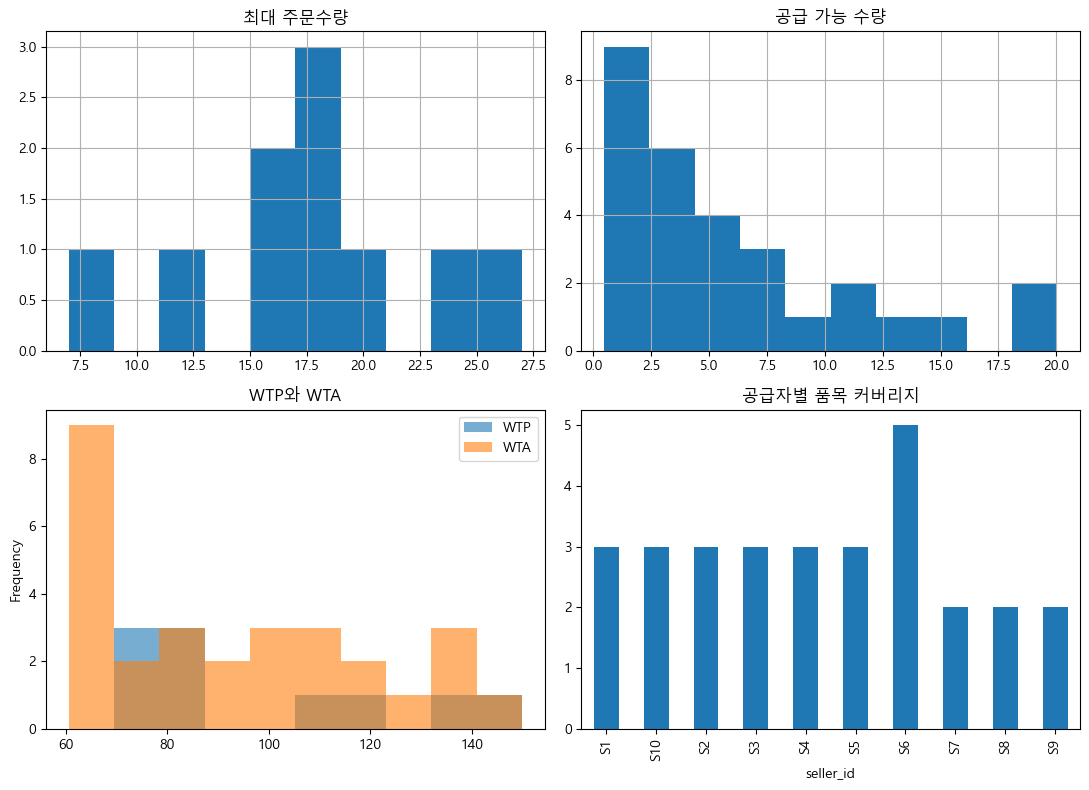

count    8.00000
mean     1.25000
std      0.46291
min      1.00000
25%      1.00000
50%      1.00000
75%      1.25000
max      2.00000
Name: 구매자별 주문 품목 수, dtype: float64

count    10.000000
mean      2.900000
std       0.875595
min       2.000000
25%       2.250000
50%       3.000000
75%       3.000000
max       5.000000
Name: 공급자별 취급 품목 수, dtype: float64

In [8]:
# 수량, 가격, 주문 품목 수, 공급자 커버리지의 간단한 그래프를 그린다.
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
buyers_df["max_qty"].hist(ax=axes[0, 0]); axes[0, 0].set_title("최대 주문수량")
sellers_df["capacity"].hist(ax=axes[0, 1]); axes[0, 1].set_title("공급 가능 수량")
pd.concat([buyers_df["wtp"].rename("WTP"), sellers_df["wta"].rename("WTA")], axis=1).plot.hist(alpha=.6, ax=axes[1, 0]); axes[1, 0].set_title("WTP와 WTA")
sellers_df.groupby("seller_id")["sku_id"].nunique().plot.bar(ax=axes[1, 1]); axes[1, 1].set_title("공급자별 품목 커버리지")
plt.tight_layout(); plt.show()
display(buyers_df.groupby("buyer_id")["sku_id"].nunique().describe().rename("구매자별 주문 품목 수"))
display(sellers_df.groupby("seller_id")["sku_id"].nunique().describe().rename("공급자별 취급 품목 수"))

In [9]:
# 하나라도 실패하면 조건과 메시지를 모아 명확히 중단한다.
failures = results.loc[~results["passed"], ["check", "failure_message"]]
if not failures.empty:
    detail = "\n".join(f"- {row.check}: {row.failure_message}" for row in failures.itertuples())
    raise AssertionError("합성 인스턴스 검증 실패:\n" + detail)
print(f"모든 {len(results)}개 검증을 통과했습니다. validation.py 결과:", library_validation)

모든 12개 검증을 통과했습니다. validation.py 결과: {'valid': True, 'checks': {'positive_counts': True, 'seller_has_item': True, 'every_item_has_seller': True, 'buyer_has_item': True, 'min_le_max': True, 'nonnegative_demand': True, 'nonnegative_supply': True, 'nonnegative_prices': True, 'nonnegative_delivery': True, 'tradable_triples': True}, 'failures': [], 'tradable_triple_count': 56}
